# Model accuracy against the adjudicated gold labels

`data/adjudicated-all-rounds.csv` is the gold standard, plus the round units that never
needed adjudication because both coders already assigned the same codes. Together that is
the full 500-unit round.

Half the gold units are held out. Few-shot examples, coding statistics and retrieved
neighbours come from the training half only. The model is scored on the test half.

Headline = micro-F1 on codes used ≥8 times in **train**. All-codes = the full codebook.

In [37]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

for _name in list(sys.modules):
    if _name == "thematic_ai" or _name.startswith("thematic_ai."):
        del sys.modules[_name]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from thematic_ai import RunConfig, annotate_units, evaluate_run, frequent_codes, refine_run
from thematic_ai.pipeline import load_workspace, make_context_builder, make_system_prompt

pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 80)

EVAL_DIR = PROJECT_ROOT / "outputs" / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

## 1. Gold labels

In [38]:
TEST_SIZE = 0.5
ws = load_workspace(RunConfig(), test_size=TEST_SIZE)
CORE = frequent_codes(ws.train, min_support=8)

print(ws.describe().to_string())
print(
    f"\ntrain {len(ws.train)} units  |  test {len(ws.test)} units  |  "
    f"overlap {len(set(ws.train['unit_id']) & set(ws.test['unit_id']))}"
)
print(f"headline codes ({len(CORE)}), each used ≥8 times in train:")
print("  " + "; ".join(CORE))

split_counts = pd.DataFrame(
    {
        "units": [len(ws.train), len(ws.test)],
        "gold assignments": [
            int(ws.train["n_gold_codes"].sum()),
            int(ws.test["n_gold_codes"].sum()),
        ],
        "mean codes per unit": [
            round(float(ws.train["n_gold_codes"].mean()), 3),
            round(float(ws.test["n_gold_codes"].mean()), 3),
        ],
    },
    index=["train", "test"],
)
display(split_counts)

codes_in_codebook             44.000
units_in_corpus             1450.000
units_human_coded              0.000
units_adjudicated            500.000
train_units                  250.000
test_units                   250.000
unlabelled_units             950.000
gold_labels_total            809.000
mean_codes_per_gold_unit       1.618

train 250 units  |  test 250 units  |  overlap 0
headline codes (10), each used ≥8 times in train:
  Hate speech and offensive language; Threats of violence; No offensive content; Death wish; Consistent offensive behavior; Normal behavior; positive content; One-off offensive; Harm other person; Majority offesnive


,units,gold assignments,mean codes per unit
train,250,403,1.612
test,250,406,1.624


## 2. Code the held-out test units

Training units supply demonstrations and calibration statistics. Cached answers are reused
when the prompt and neighbours match. The calibrated run then goes through a second
adjudication pass.

In [39]:
BACKEND = "openai"
MODEL = "gpt-5.1"
# The improved path is calibrated + second-pass adjudication. codebook_only and
# few_shot also receive the error-derived rules; add them here to compare.
VARIANTS = ("calibrated",)

RESULTS = {}
test_units = ws.test

for variant in VARIANTS:
    config = RunConfig(
        backend=BACKEND,
        model=MODEL,
        prompt_variant=variant,
        run_label="test_split",
    )
    print(f"\n{config.backend}:{config.model} | {variant} | {len(test_units)} units")
    run = annotate_units(
        test_units,
        ws.codebook,
        config,
        make_system_prompt(ws, config),
        context_builder=make_context_builder(ws, config),
        progress=lambda done, total: print(f"  {done}/{total}", end="\r"),
    )
    if variant == "calibrated":
        print("\n  adjudicating...")
        run = refine_run(run, ws, progress=lambda done, total: print(f"  {done}/{total}", end="\r"))
    run.save(PROJECT_ROOT / "outputs", prefix="eval")
    full = evaluate_run(run, ws.gold_labels, ws.codebook)
    core = evaluate_run(run, ws.gold_labels, ws.codebook, codes=CORE)
    RESULTS[variant] = {"run": run, "full": full, "core": core, "config": config}
    print(
        f"\n  headline micro-F1 {core.overall['micro_f1']:.3f}  |  "
        f"all-codes micro-F1 {full.overall['micro_f1']:.3f}"
    )


openai:gpt-5.1 | calibrated | 250 units
  250/250
  adjudicating...
  250/250
  headline micro-F1 0.810  |  all-codes micro-F1 0.740


## 3. Accuracy vs gold (held-out test)

Headline = codes used ≥8 times in train. All codes = the full codebook.

,prompt_variant,scope,n_codes_evaluated,gold_labels,pred_labels,micro_precision,micro_recall,micro_f1,exact_set_match
0,calibrated,headline,10,327,325,0.812,0.807,0.81,0.600
1,calibrated,all codes,44,405,446,0.706,0.778,0.74,0.476


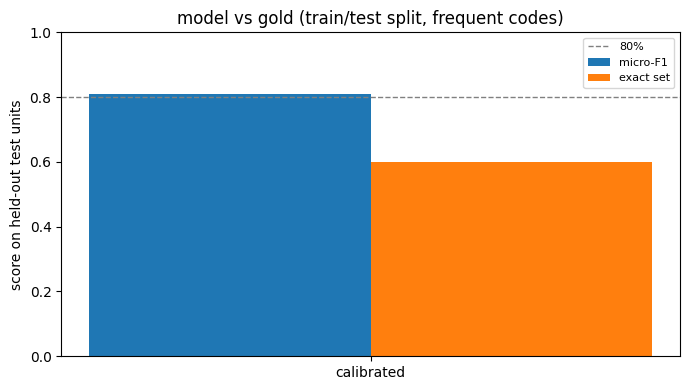

In [40]:
rows = []
for variant, entry in RESULTS.items():
    for scope, result in (("headline", entry["core"]), ("all codes", entry["full"])):
        rows.append(
            {
                "prompt_variant": variant,
                "scope": scope,
                **result.overall,
            }
        )
summary = pd.DataFrame(rows)
cols = [
    "prompt_variant", "scope", "n_codes_evaluated", "gold_labels", "pred_labels",
    "micro_precision", "micro_recall", "micro_f1", "exact_set_match",
]
display(summary[cols].round(3))
summary.to_csv(EVAL_DIR / "summary__notebook.csv", index=False)

headline = summary[summary["scope"] == "headline"]
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(headline))
ax.bar(x - 0.2, headline["micro_f1"], width=0.4, label="micro-F1")
ax.bar(x + 0.2, headline["exact_set_match"], width=0.4, label="exact set")
ax.axhline(0.80, ls="--", color="grey", lw=1, label="80%")
ax.set_xticks(x, headline["prompt_variant"])
ax.set_ylim(0, 1)
ax.set_ylabel("score on held-out test units")
ax.set_title("model vs gold (train/test split, frequent codes)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Per-code and per-theme

In [41]:
VARIANT = "calibrated"
result = RESULTS[VARIANT]["core"]
full = RESULTS[VARIANT]["full"]
print("frequent codes")
display(
    result.per_code[result.per_code["support_gold"] > 0]
    [["code", "support_gold", "support_pred", "precision", "recall", "f1"]]
    .round(3)
)
print("all codebook codes with any gold or predicted support")
display(
    full.per_code[(full.per_code["support_gold"] > 0) | (full.per_code["support_pred"] > 0)]
    [["code", "support_gold", "support_pred", "precision", "recall", "f1"]]
    .round(3)
)
full.per_code.to_csv(EVAL_DIR / f"per_code__{BACKEND}__{MODEL}__{VARIANT}.csv", index=False)

frequent codes


,code,support_gold,support_pred,precision,recall,f1
0,Hate speech and offensive language,97,97,0.845,0.845,0.845
1,Threats of violence,62,51,0.902,0.742,0.814
2,No offensive content,58,51,0.980,0.862,0.917
3,Consistent offensive behavior,32,42,0.667,0.875,0.757
4,Death wish,28,28,0.821,0.821,0.821
5,Majority offesnive,19,18,0.889,0.842,0.865
6,Normal behavior,9,10,0.500,0.556,0.526
7,positive content,8,11,0.455,0.625,0.526
8,One-off offensive,7,6,0.833,0.714,0.769
9,Harm other person,7,11,0.364,0.571,0.444


all codebook codes with any gold or predicted support


,code,support_gold,support_pred,precision,recall,f1
0,Hate speech and offensive language,97,97,0.845,0.845,0.845
1,Threats of violence,62,51,0.902,0.742,0.814
2,No offensive content,58,51,0.980,0.862,0.917
3,Consistent offensive behavior,32,42,0.667,0.875,0.757
4,Death wish,28,28,0.821,0.821,0.821
5,Majority offesnive,19,18,0.889,0.842,0.865
6,Normal behavior,9,10,0.500,0.556,0.526
7,one message is enough (offensive),9,7,0.571,0.444,0.500
8,positive content,8,11,0.455,0.625,0.526
9,One-off offensive,7,6,0.833,0.714,0.769


## 5. Units that differ from gold

In [42]:
errors = result.errors
print(f"{len(errors)} of {result.overall['n_units']} test units differ on the frequent codes")
display(errors[["unit_text", "gold_codes", "pred_codes", "missed", "spurious"]].head(20))

100 of 250 test units differ on the frequent codes


,unit_text,gold_codes,pred_codes,missed,spurious
0,The account should be suspended. Every comment is offensive.,Consistent offensive behavior,Consistent offensive behavior; Hate speech and offensive language,,Hate speech and offensive language
1,Every comment was offensive. The account should be suspended.,Consistent offensive behavior,Consistent offensive behavior; Hate speech and offensive language,,Hate speech and offensive language
2,I think they have potential to be better but they said waaay too many awful ...,Consistent offensive behavior; Majority offesnive,Consistent offensive behavior,Majority offesnive,
3,The person kept giving off ignorant responses in majority of their post.,Majority offesnive,Consistent offensive behavior; Majority offesnive,,Consistent offensive behavior
4,"The third message contained a death threat, and was violent and offensive en...",Death wish; Threats of violence,Death wish,Threats of violence,
5,I decided to Suspend Account 5 because of their threats of murder in their m...,Threats of violence,Consistent offensive behavior; Threats of violence,,Consistent offensive behavior
6,"Even though there are some very calm and eloquent messages, there are still ...",Hate speech and offensive language,Harm other person; Hate speech and offensive language,,Harm other person
7,"Though one message did include a threat of violence and use of a slur, this ...",One-off offensive; Threats of violence,Hate speech and offensive language; One-off offensive; Threats of violence,,Hate speech and offensive language
8,Account 5 contains nothing but hurtful and suicidal comments that have only ...,Consistent offensive behavior; Death wish,Consistent offensive behavior; Death wish; Harm other person,,Harm other person
9,"name calling, deorgatory comments",Hate speech and offensive language,,Hate speech and offensive language,


In [43]:
print("per theme (any code in the theme present)")
display(
    full.per_theme[["theme", "support_gold", "support_pred", "precision", "recall", "f1"]]
    .round(3)
)
full.per_theme.to_csv(EVAL_DIR / f"per_theme__{BACKEND}__{MODEL}__{VARIANT}.csv", index=False)
full.errors.to_csv(EVAL_DIR / f"errors__{BACKEND}__{MODEL}__{VARIANT}.csv", index=False)
print(f"{len(full.errors)} of {full.overall['n_units']} units differ from gold on the full codebook")

per theme (any code in the theme present)


,theme,support_gold,support_pred,precision,recall,f1
0,Type of offensiveness,202,205,0.932,0.946,0.939
1,Patterns of behavior,72,85,0.776,0.917,0.841
2,Justifications,15,19,0.632,0.800,0.706
3,Decision outcomes,15,12,0.750,0.600,0.667
4,Positive content,13,18,0.556,0.769,0.645
5,Reflection on the decision,8,12,0.583,0.875,0.700


131 of 250 units differ from gold on the full codebook
